### o	Programming exercise for Normalization and Regularization<br> o	Early stopping, dropouts and other methods for data normalization

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


In [2]:
(x_train,y_train),(x_test,y_test)=tf.keras.datasets.fashion_mnist.load_data()

In [3]:
x_train.shape # 60000->no.of rows, 28,28-.size of one pixel

(60000, 28, 28)

In [4]:
x_test.shape #10000->no.of rows, 28,28-.size of one pixel

(10000, 28, 28)

In [5]:
x_train[0].max()# check the max value of one pixel in training dataset

255

In [6]:
x_test[0].max()

255

In [7]:
x_train=x_train/255
x_test=x_test/255

In [8]:
x_train[8]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.00392157, 0.01176471, 0.00392157,
        0.        , 0.    

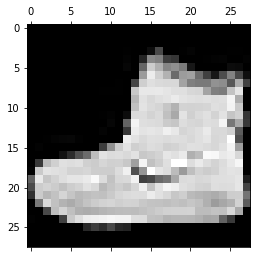

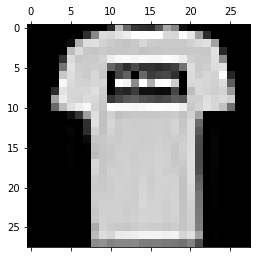

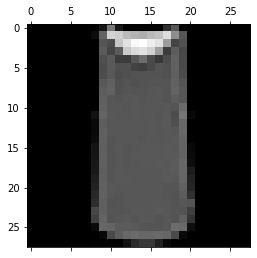

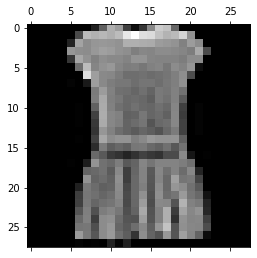

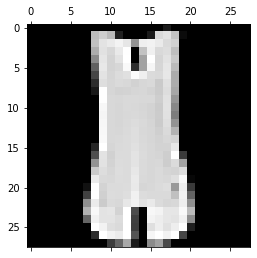

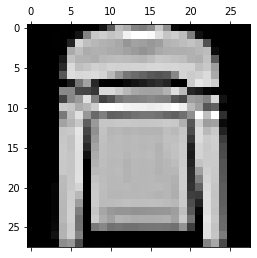

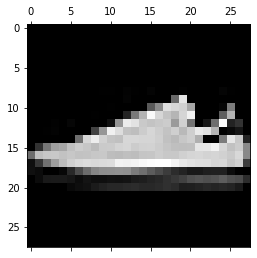

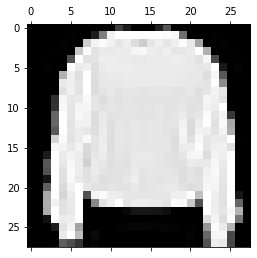

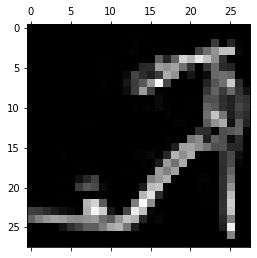

In [9]:
for i in range(9):
    plt.matshow(x_train[i],cmap='gray')
plt.show()



In [10]:
len(x_train)

60000

In [23]:
x_train_flat=x_train.reshape(len(x_train),28*28)
x_test_flat=x_test.reshape(len(x_test),28*28)
print(x_train_flat.shape)

(60000, 784)


In [24]:
x_train_flat[8]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.00392157, 0.01176471,
       0.00392157, 0.        , 0.        , 0.00392157, 0.00392

In [28]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping

from keras import models


model = Sequential([
    keras.layers.Dense(10,input_shape=(784,),activation='sigmoid'),
    
])


In [29]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [30]:
model.fit(x_train_flat,y_train,epochs=20)

Epoch 1/20
1875/1875 [==============================] - 2s 753us/step - loss: 0.5943 - accuracy: 0.8016
Epoch 2/20
1875/1875 [==============================] - 1s 750us/step - loss: 0.4610 - accuracy: 0.8425
Epoch 3/20
1875/1875 [==============================] - 1s 742us/step - loss: 0.4340 - accuracy: 0.8497
Epoch 4/20
1875/1875 [==============================] - 1s 759us/step - loss: 0.4219 - accuracy: 0.8547
Epoch 5/20
1875/1875 [==============================] - 1s 771us/step - loss: 0.4133 - accuracy: 0.8577
Epoch 6/20
1875/1875 [==============================] - 1s 762us/step - loss: 0.4077 - accuracy: 0.8592
Epoch 7/20
1875/1875 [==============================] - 2s 802us/step - loss: 0.4022 - accuracy: 0.8602
Epoch 8/20
1875/1875 [==============================] - 1s 769us/step - loss: 0.3983 - accuracy: 0.8619
Epoch 9/20
1875/1875 [==============================] - 1s 759us/step - loss: 0.3945 - accuracy: 0.8636
Epoch 10/20
1875/1875 [==============================] - 1s 753u

In [31]:
model.evaluate(x_test_flat,y_test)

313/313 [==============================] - 0s 683us/step - loss: 0.4464 - accuracy: 0.8415


[0.4463611841201782, 0.8414999842643738]

In [32]:
y_predict=model.predict(x_test_flat)
y_predict

313/313 [==============================] - 0s 558us/step


array([[3.6241955e-04, 1.6716293e-06, 1.1480923e-02, ..., 9.7208226e-01,
        8.5021842e-01, 9.9842834e-01],
       [1.2211326e-02, 1.3660514e-06, 9.8483157e-01, ..., 2.5973308e-35,
        3.6985081e-04, 2.0568849e-20],
       [8.9029765e-01, 9.9999547e-01, 5.2897733e-01, ..., 1.6557298e-15,
        3.5143446e-03, 1.4032354e-09],
       ...,
       [8.2911909e-01, 3.5435238e-05, 1.6003101e-01, ..., 2.8433866e-05,
        9.5316720e-01, 3.9910333e-08],
       [1.3908093e-01, 9.9999404e-01, 1.4365701e-01, ..., 5.5858496e-10,
        9.2571072e-04, 1.2413528e-03],
       [8.7036835e-03, 6.6349679e-04, 1.2596424e-01, ..., 7.0666665e-01,
        5.4886699e-01, 2.5116466e-02]], dtype=float32)

In [88]:
model1 = Sequential([
    Dense(10,input_shape=(784,)),
    Dropout(0.2),
    Dense(128,activation='sigmoid'),
    Dropout(0.1),
    Dense(10,activation='softmax')
])

In [89]:
model1.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [90]:
callbacks=[EarlyStopping(monitor='val_accuracy',patience=3)]
model1.fit(x_train_flat,y_train,epochs=100,batch_size=20000,validation_split=0.2,callbacks=callbacks)

Epoch 1/100
3/3 [==============================] - 1s 105ms/step - loss: 2.4770 - accuracy: 0.0946 - val_loss: 2.3452 - val_accuracy: 0.0983
Epoch 2/100
3/3 [==============================] - 0s 57ms/step - loss: 2.3424 - accuracy: 0.1250 - val_loss: 2.2525 - val_accuracy: 0.2183
Epoch 3/100
3/3 [==============================] - 0s 56ms/step - loss: 2.2633 - accuracy: 0.1689 - val_loss: 2.1959 - val_accuracy: 0.2448
Epoch 4/100
3/3 [==============================] - 0s 57ms/step - loss: 2.2145 - accuracy: 0.1771 - val_loss: 2.1491 - val_accuracy: 0.2567
Epoch 5/100
3/3 [==============================] - 0s 57ms/step - loss: 2.1689 - accuracy: 0.1943 - val_loss: 2.0956 - val_accuracy: 0.2363
Epoch 6/100
3/3 [==============================] - 0s 56ms/step - loss: 2.1165 - accuracy: 0.2198 - val_loss: 2.0317 - val_accuracy: 0.2346
Epoch 7/100
3/3 [==============================] - 0s 57ms/step - loss: 2.0541 - accuracy: 0.2599 - val_loss: 1.9606 - val_accuracy: 0.3512
Epoch 8/100
3/3 [==

In [91]:
r=model1.evaluate(x_test_flat,y_test)


313/313 [==============================] - 0s 699us/step - loss: 0.5787 - accuracy: 0.7937


In [92]:
print('test loss,test acc: ',r)

test loss,test acc:  [0.5786784887313843, 0.7936999797821045]


In [93]:
model2 = Sequential([
    Dense(10,input_shape=(784,)),
    Dropout(0.2),
    Dense(128,activation='sigmoid'),
    Dropout(0.1),
    Dense(10,activation='softmax')
])

In [95]:
model2.compile(optimizer='sgd',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [96]:
callbacks=[EarlyStopping(monitor='val_accuracy',patience=3)]
model2.fit(x_train_flat,y_train,epochs=100,batch_size=20000,validation_split=0.2,callbacks=callbacks)

Epoch 1/100
3/3 [==============================] - 1s 105ms/step - loss: 2.4577 - accuracy: 0.1001 - val_loss: 2.4132 - val_accuracy: 0.0983
Epoch 2/100
3/3 [==============================] - 0s 55ms/step - loss: 2.4264 - accuracy: 0.0996 - val_loss: 2.3875 - val_accuracy: 0.0983
Epoch 3/100
3/3 [==============================] - 0s 67ms/step - loss: 2.4014 - accuracy: 0.1006 - val_loss: 2.3670 - val_accuracy: 0.0983
Epoch 4/100
3/3 [==============================] - 0s 61ms/step - loss: 2.3828 - accuracy: 0.1000 - val_loss: 2.3504 - val_accuracy: 0.0985
Epoch 5/100
3/3 [==============================] - 0s 57ms/step - loss: 2.3676 - accuracy: 0.1044 - val_loss: 2.3366 - val_accuracy: 0.1018
Epoch 6/100
3/3 [==============================] - 0s 56ms/step - loss: 2.3548 - accuracy: 0.1050 - val_loss: 2.3253 - val_accuracy: 0.1090
Epoch 7/100
3/3 [==============================] - 0s 60ms/step - loss: 2.3441 - accuracy: 0.1072 - val_loss: 2.3158 - val_accuracy: 0.1193
Epoch 8/100
3/3 [==

In [97]:
r2=model2.evaluate(x_test_flat,y_test)

313/313 [==============================] - 0s 943us/step - loss: 1.9989 - accuracy: 0.4904


In [98]:
print('test loss,test acc: ',r2)

test loss,test acc:  [1.9988982677459717, 0.4903999865055084]


In [99]:
model3 = Sequential([
    Dense(10,input_shape=(784,)),
    Dropout(0.2),
    Dense(128,activation='sigmoid'),
    Dropout(0.1),
    Dense(10,activation='softmax')
])

In [100]:
model3.compile(optimizer='Adagrad',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [101]:
callbacks=[EarlyStopping(monitor='val_accuracy',patience=3)]
model3.fit(x_train_flat,y_train,epochs=100,batch_size=20000,validation_split=0.2,callbacks=callbacks)

Epoch 1/100
3/3 [==============================] - 1s 108ms/step - loss: 2.4349 - accuracy: 0.1015 - val_loss: 2.4057 - val_accuracy: 0.0889
Epoch 2/100
3/3 [==============================] - 0s 56ms/step - loss: 2.4274 - accuracy: 0.1024 - val_loss: 2.3998 - val_accuracy: 0.0880
Epoch 3/100
3/3 [==============================] - 0s 60ms/step - loss: 2.4207 - accuracy: 0.1031 - val_loss: 2.3942 - val_accuracy: 0.0872
Epoch 4/100
3/3 [==============================] - 0s 60ms/step - loss: 2.4169 - accuracy: 0.1016 - val_loss: 2.3889 - val_accuracy: 0.0856


In [102]:
r3=model3.evaluate(x_test_flat,y_test)

313/313 [==============================] - 0s 786us/step - loss: 2.3886 - accuracy: 0.0852


In [103]:
print('test loss,test acc: ',r3)

test loss,test acc:  [2.388580799102783, 0.0851999968290329]
